In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pymc as pm
import pytensor
import pytensor.tensor as pt
import japanize_matplotlib
import arviz as az

In [2]:
df = pd.read_csv("../data/eyam_plague.csv")
df.head()

,t_months,S,I
0,0.0,254,7
1,0.5,235,14
2,1.0,201,22
3,1.5,153,29
4,2.0,121,20


In [4]:
t_obs = df["t_months"].values
S_obs = df["S"].values
I_obs = df["I"].values
N_pop = 261

n_steps_per_interval = 50
dt = 0.5 / n_steps_per_interval

In [5]:
with pm.Model() as sir_model:
    beta = pm.Gamma("beta", alpha=4, beta=4/5)
    gamma = pm.Gamma("gamma", alpha=4, beta=4/3.4)

    S0 = pm.Data("S0", float(S_obs[0]))
    I0 = pm.Data("I0", float(I_obs[0]))

    def euler_step(S_prev, I_prev, beta, gamma, N, dt):
        dS =  -beta * S_prev * I_prev / N * dt
        dI = ( beta * S_prev * I_prev / N - gamma * I_prev) * dt
        S_new = S_prev + dS
        I_new = pt.maximum(I_prev + dI, 0.0)
        return S_new, I_new

    total_steps = n_steps_per_interval * (len(t_obs) - 1)

    (S_path, I_path), _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[S0, I0],
        non_sequences=[beta, gamma, N_pop, dt],
        n_steps=total_steps,
    )

    idx = pt.arange(n_steps_per_interval - 1, total_steps, n_steps_per_interval)
    S_pred_obs = pt.concatenate([[S0], S_path[idx]])
    I_pred_obs = pt.concatenate([[I0], I_path[idx]])

    pm.Deterministic("S_pred", S_pred_obs)
    pm.Deterministic("I_pred", I_pred_obs)

    pm.Poisson("S_obs_lik", mu=pt.maximum(S_pred_obs, 0.1), observed=S_obs)
    pm.Poisson("I_obs_lik", mu=pt.maximum(I_pred_obs, 0.1), observed=I_obs)

    

/tmp/ipykernel_67446/1499209561.py:17: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  (S_path, I_path), _ = pytensor.scan(


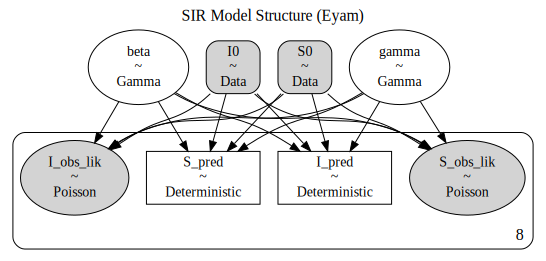

In [9]:
g = pm.model_to_graphviz(sir_model)

g.graph_attr.update(
    label="SIR Model Structure (Eyam)",
    labelloc="t",
    fontsize="16"
)
g.render(filename="../models/sir_model_graph", format="png", cleanup=True)
g

In [10]:
with sir_model:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
    

Sampling: [I_obs_lik, S_obs_lik, beta, gamma]


In [11]:
prior

<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:       (chain: 1, draw: 200, S_pred_dim_0: 8, I_pred_dim_0: 8)
│       Coordinates:
│         * chain         (chain) int64 8B 0
│         * draw          (draw) int64 2kB 0 1 2 3 4 5 6 ... 193 194 195 196 197 198 199
│         * S_pred_dim_0  (S_pred_dim_0) int64 64B 0 1 2 3 4 5 6 7
│         * I_pred_dim_0  (I_pred_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           beta          (chain, draw) float64 2kB 8.29 2.066 8.61 ... 4.454 4.559
│           gamma         (chain, draw) float64 2kB 3.848 3.164 6.159 ... 3.55 4.149
│           S_pred        (chain, draw, S_pred_dim_0) float64 13kB 254.0 186.5 ... 187.4
│           I_pred        (chain, draw, I_pred_dim_0) float64 13kB 7.0 37.22 ... 1.395
│       Attributes:
│           created_at:                 2026-07-14T04:41:43.684233+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:          (chain: 1, draw: 200, S_obs_lik_dim_0: 8,
│                             I_obs_lik_dim_0: 8)
│       Coordinates:
│         * chain            (chain) int64 8B 0
│         * draw             (draw) int64 2kB 0 1 2 3 4 5 6 ... 194 195 196 197 198 199
│         * S_obs_lik_dim_0  (S_obs_lik_dim_0) int64 64B 0 1 2 3 4 5 6 7
│         * I_obs_lik_dim_0  (I_obs_lik_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           S_obs_lik        (chain, draw, S_obs_lik_dim_0) int64 13kB 225 161 ... 196
│           I_obs_lik        (chain, draw, I_obs_lik_dim_0) int64 13kB 4 39 58 ... 2 0 5
│       Attributes:
│           created_at:                 2026-07-14T04:41:43.687428+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:          (S_obs_lik_dim_0: 8, I_obs_lik_dim_0: 8)
│       Coordinates:
│         * S_obs_lik_dim_0  (S_obs_lik_dim_0) int64 64B 0 1 2 3 4 5 6 7
│         * I_obs_lik_dim_0  (I_obs_lik_dim_0) int64 64B 0 1 2 3 4 5 6 7
│       Data variables:
│           S_obs_lik        (S_obs_lik_dim_0) int64 64B 254 235 201 153 121 110 97 83
│           I_obs_lik        (I_obs_lik_dim_0) int64 64B 7 14 22 29 20 8 8 0
│       Attributes:
│           created_at:                 2026-07-14T04:41:43.688749+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:  ()
        Data variables:
            S0       float64 8B 254.0
            I0       float64 8B 7.0
        Attributes:
            created_at:                 2026-07-14T04:41:43.689468+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.1
            sample_dims:                []

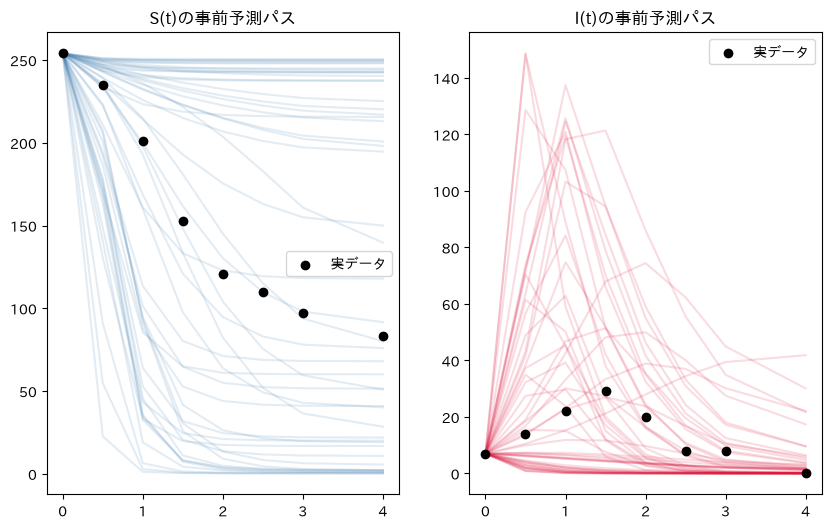

In [12]:
S_pred_prior = prior.prior["S_pred"].values.reshape(-1, len(t_obs))
I_pred_prior = prior.prior["I_pred"].values.reshape(-1, len(t_obs))

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for i in range(50):
    axes[0].plot(t_obs, S_pred_prior[i], color="steelblue", alpha=0.15)
    axes[1].plot(t_obs, I_pred_prior[i], color="crimson", alpha=0.15)
axes[0].scatter(t_obs, S_obs, color="black", zorder=5, label="実データ")
axes[1].scatter(t_obs, I_obs, color="black", zorder=5, label="実データ")
axes[0].set_title("S(t)の事前予測パス"); axes[0].legend()
axes[1].set_title("I(t)の事前予測パス"); axes[1].legend()
plt.savefig("../img/sir_prior_check_v0.png", dpi=100)

In [13]:
print("S_pred の最小値:", S_pred_prior.min(), "最大値:", S_pred_prior.max())
print("I_pred の最小値:", I_pred_prior.min(), "最大値:", I_pred_prior.max())

S_pred の最小値: 0.014779416192935258 最大値: 254.0
I_pred の最小値: 3.13440285003344e-10 最大値: 186.22169873721438


In [14]:
with sir_model:
    idata = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95,
        nuts_sampler="numpyro",
        random_seed=42
    )

NUTS[numpyro]: [beta, gamma]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Compiling.. :   0%| | 0/4000 [00:00
  0%|     | 0/4000 [00:00<?, ?it/s]
Compiling.. :   0%| | 0/4000 [00:00

  0%|     | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%| | 0/4000 [00:00


  0%|     | 0/4000 [00:00<?, ?it/s]


Running chain 0:   0%| | 0/4000 [00
Running chain 1:   0%| | 0/4000 [00

Running chain 2:   0%| | 0/4000 [00


Running chain 3:   0%| | 0/4000 [00

Running chain 2:  10%| | 400/4000 [


Running chain 0:  10%| | 400/4000 [
Running chain 1:  10%| | 400/4000 [
Running chain 0:  30%|▎| 1200/4000 

Running chain 2:  30%|▎| 1200/4000 


Running chain 3:  30%|▎| 1200/4000 
Running chain 1:  45%|▍| 1800/4000 


Running chain 3:  50%|▌| 2000/4000 

Running chain 0:  50%|▌| 2000/4000 
Running chain 1:  60%|▌| 2400/4000 


Running chain 3:  65%|▋| 2600/4000 

Running chain 0:  70%|▋| 2800/4000 
Running chain 1:  75%|▊| 3000/4000 


Running c

In [15]:
print("divergences:", int(idata.sample_stats["diverging"].sum()))
az.summary(idata, var_names=["beta", "gamma"])

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta,5.04,0.225,4.7,5.4,1861,2052,1.00,0.0052,0.0036
gamma,3.169,0.174,2.9,3.5,1897,2141,1.00,0.004,0.0028


モデルのピーク: t=1.5, I=24.7
実データのピーク: t=1.5, I=29
t=1.5でのモデル予測: I_median=24.7, 90%区間=[22.0, 27.5]


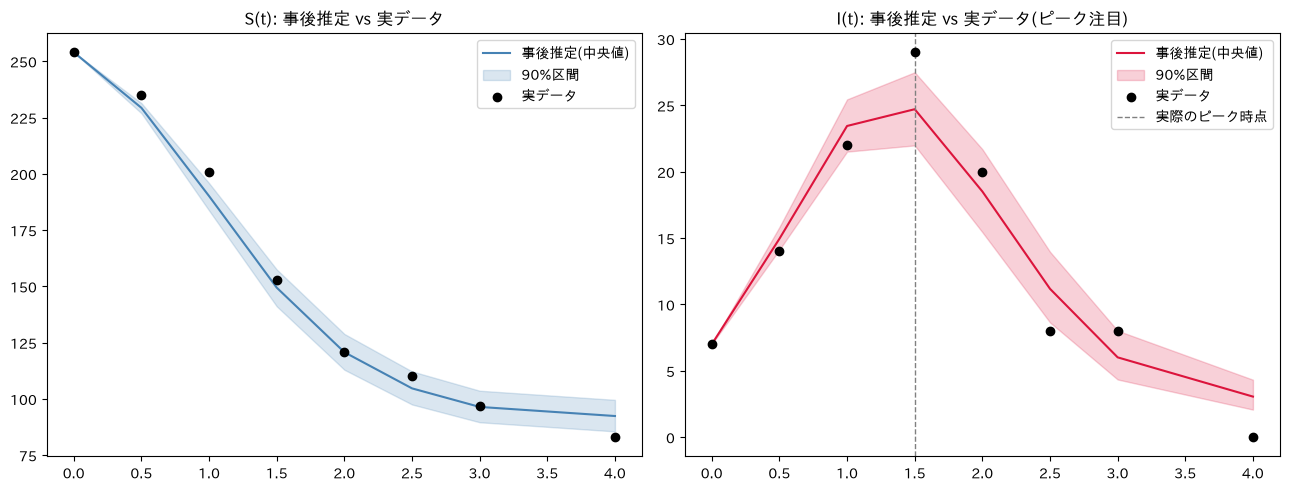

In [16]:
S_pred_post = idata.posterior["S_pred"].stack(sample=("chain", "draw")).values
I_pred_post = idata.posterior["I_pred"].stack(sample=("chain", "draw")).values

I_median = np.median(I_pred_post, axis=1)
I_lower = np.percentile(I_pred_post, 5, axis=1)
I_upper = np.percentile(I_pred_post, 95, axis=1)

S_median = np.median(S_pred_post, axis=1)
S_lower = np.percentile(S_pred_post, 5, axis=1)
S_upper = np.percentile(S_pred_post, 95, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_obs, S_median, color="steelblue", label="事後推定(中央値)")
axes[0].fill_between(t_obs, S_lower, S_upper, color="steelblue", alpha=0.2, label="90%区間")
axes[0].scatter(t_obs, S_obs, color="black", zorder=5, label="実データ")
axes[0].legend(); axes[0].set_title("S(t): 事後推定 vs 実データ")

axes[1].plot(t_obs, I_median, color="crimson", label="事後推定(中央値)")
axes[1].fill_between(t_obs, I_lower, I_upper, color="crimson", alpha=0.2, label="90%区間")
axes[1].scatter(t_obs, I_obs, color="black", zorder=5, label="実データ")
axes[1].axvline(1.5, color="gray", ls="--", lw=1, label="実際のピーク時点")
axes[1].legend(); axes[1].set_title("I(t): 事後推定 vs 実データ(ピーク注目)")

plt.tight_layout()
plt.savefig("../img/sir_posterior_check.png", dpi=100)

# ピーク時点・ピーク値の数値比較
peak_idx_model = np.argmax(I_median)
print(f"モデルのピーク: t={t_obs[peak_idx_model]}, I={I_median[peak_idx_model]:.1f}")
print(f"実データのピーク: t=1.5, I=29")
print(f"t=1.5でのモデル予測: I_median={I_median[3]:.1f}, 90%区間=[{I_lower[3]:.1f}, {I_upper[3]:.1f}]")

# Eyamペスト流行(1666年) SIR機構モデル セッションサマリー

## 目的

これまでの統計モデル(SV, MSM, 階層ベイズ, Hawkes過程)とは異なり、**微分方程式で感染・回復のメカニズムそのものを記述する機構論的モデル**にベイズ推定を適用する。1666年イギリス・Eyam村のペスト流行という、SIRモデリングの古典的定番データを用いた。

## データ

- Raggett, G.F. (1982) "A stochastic model of the Eyam plague." *Journal of Applied Statistics* 9, 212-226. で報告された、埋葬記録から逆算されたS(感受性人口)・I(感染者数)の8時点の観測(1666年6月18日〜10月20日、0〜4ヶ月、0.5ヶ月間隔)
- 複数の学術論文(arXiv含む)で同一の表が引用されている定番データセット。村が自主隔離したため「人口が固定されている」という前提がSIRモデルと相性が良い
- N=261(村の総人口)、S: 254→83、I: 7→29(t=1.5でピーク)→0

## モデル構造

$$\frac{dS}{dt}=-\beta SI/N, \qquad \frac{dI}{dt}=\beta SI/N-\gamma I$$

- **これまでとの最大の違い**: 尤度の計算に先立ち、`pytensor.scan`でオイラー法による数値積分を行い、粗い観測間隔(0.5ヶ月)の間を細分化(50ステップ)して$S(t),I(t)$の軌道を再構成する必要があった。Hawkes過程の「時間差行列」とも異なる、「1ステップ前の状態から次状態を計算する逐次更新」という新しい実装パターン。
- 観測尤度は$S,I$とも**Poisson分布**を採用(「村の記録という同一の観測プロセスから生じた人数データ」という理由付けで、両者を同じ分布族に揃えた)。

## 事前分布の設計における紆余曲折

初期提案では$\beta,\gamma$がともに2.0〜4.0という同スケールで検討されたが、これは$R_0=\beta/\gamma\approx1$を意味し、村の人口の大部分が感染した実際の流行規模と整合しないことを指摘。さらに、$\beta$が$dS/dt=-\beta SI/N$という式で**$SI/N$という既に大きな項に掛かる**ことを見落としていた点も修正。

データから$\beta$のスケールを逆算($t=1\to1.5$の区間の$\Delta S$と$SI/N$の比から$\beta\approx5.5$)したところ、**Raggett(1982)原論文の推定値$\hat\beta=0.0212$(定義が$dS/dt=-\beta SI$、Nで割らない形)に$N\approx261$を掛けた値とほぼ一致**し、独立した検算として良い整合性が確認できた。

観測分布についても、当初Negative Binomial(過分散を許容)の提案があったが、「S・Iが同じ観測プロセス(村の記録)に由来するなら、同じ分布族で揃えるのが自然」という論点整理を経て、まずシンプルなPoissonで統一する方針とした。

## Prior predictive checkでの新しい確認事項

これまでの「分散爆発」型の病理とは異なり、SIRモデルでは **$\beta,\gamma$の事前分布サンプルの組み合わせ次第で流行の規模自体が大きく変わることが、そもそもモデルの正しい振る舞い**であるという整理を行った。事前予測の$I$の最大値が実データのピーク(29)よりかなり大きい(186)値を含んでいたが、これは「常識外れの暴走」ではなく「事前分布がまだデータを見ていない状態で、緩やかな流行〜激しい流行の両方をカバーしている」ことの表れと判断し、追加の事前分布調整は行わなかった。

## サンプリングと結果

- 診断: r_hat=1.00、divergences=0、ess数千(target_accept=0.95、ODEベースのモデルのため通常よりやや高めに設定)
- $\beta\approx5.04$(sd=0.225)、$\gamma\approx3.17$(sd=0.174)
- **$R_0=\beta/\gamma\approx1.59$**: Raggett(1982)原論文の推定値($R_0\approx1.9$)と近いオーダーで、60年以上前の古典的推定を独立したベイズアプローチで大枠再現できた。
- $1/\gamma\approx9.5$日: 感染から回復・死亡までの平均期間に相当し、ペストの臨床経過(発症から死亡まで1〜2週間程度)と整合的。

### 表現力の検証(ピーク再現性)

- ピークの**時点**は完全一致(モデル・実データともに$t=1.5$)
- ピークの**高さ**はやや過小評価(モデル中央値24.7 vs 実データ29、90%区間[22.0,27.5]は実データをわずかに外れる)
- 過小評価の原因として、$I$の観測分布に採用したPoisson分布の「分散=平均」という制約が、急激なピーク形成をやや説明しきれていない可能性を指摘。Negative Binomial(過分散許容)であれば、鋭い立ち上がりへの適合がより柔軟になった可能性がある。

---

## 主要な学び

1. **機構論的モデル(ODE)は、統計モデルとは異なる実装パターンを要求する**: `pytensor.scan`による数値積分(オイラー法)、観測間隔の細分化という、これまでの「時間差行列」(Hawkes)や「forward algorithm」(MSM)とも異なる新しいベクトル化/逐次計算パターンを習得した。
2. **パラメータのスケール感は、支配方程式の構造を正確に読み解くことで検算できる**: $\beta$が単独ではなく$SI/N$という積の形で効くことを見落とすと、事前分布のスケールが1桁以上ズレる。数式の構造(何と何が掛け合わさっているか)を丁寧に追うことが、他のモデルクラス以上に重要だった。
3. **古典的な頻度主義の推定値との比較は、ベイズ推定の妥当性検証として有効**: Raggett(1982)の$\hat\beta=0.0212$($dS/dt=-\beta SI$の定義)を、今回の$dS/dt=-\beta SI/N$の定義に変換($\times N$)して比較することで、独立した2つのアプローチの整合性を確認できた。単位・定義の違いに注意しながら他の推定と付き合わせる、という実務的なスキル。
4. **観測分布の選択(Poisson vs Negative Binomial)が、ピークのような急激な変化への適合度に影響する**: サメ・ポケモンで確立した「観測プロセスの性質に応じて分布を選ぶ」という原則を踏まえPoissonで統一したが、結果としてピークをやや過小評価する形になった。これは「観測プロセスの均一性」を優先するか「データの急激な変化への適合力」を優先するかのトレードオフとして捉えられる。

## フォローアップ候補

- $I$の観測分布をNegative Binomialに変更し、ピーク再現性が改善するか比較検証
- ルンゲクッタ法など、より精度の高い数値積分法への変更(オイラー法との結果の比較)
- Sの観測分布についても、同様の過分散を考慮したモデルとの比較
